In [1]:
import json
import os
import sys
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

root_path = Path().absolute().parent.parent
sys.path.append(str(root_path))
# print(f"Root path set to: {root_path}")
from eval_agent.user_agent.graph.user_agent_graph import build_graph 

17030
17030


/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/query_decomposer.py:37: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  self.query_analyzer = LLMChain(llm=llm, prompt=self.prompt_builder, verbose=False)


In [2]:

llm = os.getenv("LLM_MODEL")  # e.g., "gpt-4o"
provider = os.getenv("LLM_PROVIDER")  # e.g., "openai"
memory = True # True if it is the experiment of the agent with memory, False if it is the experiment of the agent without memory
database = os.getenv("EXPERIMENT_NAME")
print(f"Running evaluation for LLM: {llm}, Provider: {provider}, Memory: {memory}, Database: {database}")

# Load the experiment dataset
json_file = f'../dataset_generation/dialogue_dataset/{database}_dialogue_dataset.json'
with open(json_file, 'r', encoding='utf-8') as f:
    experiments = json.load(f)


# Build the evaluation graph with the specified memory and environment
eval_graph = build_graph(text_to_sql_agent_memory=memory, env="tec")

experiment_memory = "memory" if memory else "agent_without_memory"
# Defines the name of the file where the results will be saved
evals_filename = f'{llm}-{experiment_memory}-{database}-eval.json'

# If the file already exists, load the experiments already evaluated
if os.path.exists(evals_filename):
    with open(evals_filename, 'r', encoding='utf-8') as f:
        evals = json.load(f)
else:
    evals = []

# Current template configuration (add details of the template used here)
processed_ids = {exp["experiment_id"] for exp in evals}

# Informations to Graph State
model_version = f"{provider}-{llm}"

experiment_type = f"text2sql_evaluation_{experiment_memory}"


Running evaluation for LLM: gpt-4o, Provider: azure, Memory: True, Database: mondial


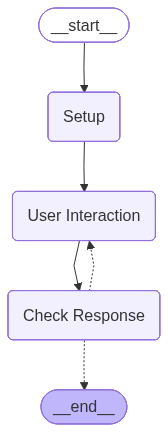

In [3]:
from IPython.display import Image, display


try:
    display(Image(eval_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [4]:
# Iterates over all experiments in the dataset
for experiment in experiments['dataset']:
    exp_id = experiment["experiment_id"]

    # Se o experimento já foi avaliado, pula para o próximo
    if exp_id in processed_ids:
        print(f"Pulando experimento {exp_id} já processado.")
        continue

    print(f"Processando experimento {exp_id}...")

    # Invoca a avaliação com as configurações estendidas
    eval_result = eval_graph.invoke({
        "experiment": experiment,
        "max_retries": 2,
        "debug_mode": True,
        "model_version": model_version,
        "experiment_type": experiment_type
    })

    print("Experimento avaliado:\n", eval_result["experiment_eval"])

    # Adiciona o resultado da avaliação junto com o ID do experimento e configuração
    evals.append({
        "experiment_id": exp_id,
        "experiment_config": eval_result.get("experiment_config", {
            "max_retries": 2,
            "model_version": model_version,
            "timestamp": datetime.now().isoformat(),
            "experiment_type": experiment_type
        }),
        "experiment_eval": eval_result["experiment_eval"]
    })

    # Atualiza o arquivo salvando o resultado atual
    with open(evals_filename, 'w', encoding='utf-8') as f:
        json.dump(evals, f, indent=4)

Processando experimento 1...
[NODE] Setup Node entered.
----------------------------------------
[NODE] User Interaction Node entered.
[INFO] Enviando a query para o agente:  Can you provide the latitude and longitude of all airports?
Decomposition
['Provide the latitude and longitude of all airports.']
(17030,)
DFE
Question: What are the locations in terms of north-south position of the airports in the database?
SELECT IATACODE, LATITUDE FROM MONDIAL_AIRPORT

Question: What are the latitude values of the airports in the MONDIAL_AIRPORT table?
SELECT IATACODE, LATITUDE FROM MONDIAL_AIRPORT

Question: What are the east-west location values of the airports in the database?
SELECT IATACODE, LONGITUDE FROM MONDIAL_AIRPORT

Question: entries with location information for each airport type
SELECT A.NAME, COUNT(D.COORDINATES) 
FROM MONDIAL_AIRPORT A 
JOIN MONDIAL_GEO_DESERT G ON A.PROVINCE = G.PROVINCE 
JOIN MONDIAL_DESERT D ON G.DESERT = D.NAME 
WHERE D.COORDINATES IS NOT NULL 
GROUP BY A.NA

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


[INFO] O resultado da execução foi: {
    "input": "Provide the latitude and longitude of all airports.",
    "schema_linking": ["airport"],
    "answer": "There are a total of 1318 airports with latitude and longitude coordinates. Here are a few examples: Airport CNF is located at latitude -19.633750 and longitude -43.968856, SLZ at latitude -2.585361 and longitude -44.234139, and CPQ at latitude -22.859200 and longitude -47.108200. Let me know if you need more details!",
    "sql": "SELECT iatacode, latitude, longitude FROM mondial_gpt.airport"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Provide the latitude and longitude of all airports.",
    "schema_linking": ["airport"],
    "answer": "There are a total of 1318 airports with latitude and longitude coordinates. Here are a few examples: Airport CNF is located at latitude -19.633750 and longitude -43.968856, SLZ at latitude -2.585361 and longitu

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


True cols: Index(['LATITUDE', 'LONGITUDE'], dtype='object')
Adj. True cols: Index(['LATITUDE', 'LONGITUDE'], dtype='object')
Predicted cols: Index(['IATACODE', 'LATITUDE', 'LONGITUDE'], dtype='object')
Adj. Predicted cols: Index(['LATITUDE', 'LONGITUDE'], dtype='object')
[INFO] A avaliação para esse turno foi:  {'interaction_id': 1, 'original_intent': 'Find the latitude and longitude of all airports.', 'total_retries_needed': 0, 'success_without_retry': True, 'turns': [{'user_query': 'Can you provide the latitude and longitude of all airports?', 'agent_reply': 'There are a total of 1318 airports with latitude and longitude coordinates. Here are a few examples: Airport CNF is located at latitude -19.633750 and longitude -43.968856, SLZ at latitude -2.585361 and longitude -44.234139, and CPQ at latitude -22.859200 and longitude -47.108200. Let me know if you need more details!', 'evaluation': {'text_to_sql_input': 'Provide the latitude and longitude of all airports.', 'user_intention': '

...

[INFO] O resultado da execução foi: {
    "input": "Find all unique provinces present in the mondial_cityothername table.",
    "schema_linking": ["mondial_cityothername"],
    "answer": "The query returned 523 rows, but it seems there are duplicate entries. Examples of provinces include Eastern Cape, Free State, Gauteng, and Punjab. To get unique provinces, further processing would be needed to remove duplicates.",
    "sql": "SELECT province FROM mondial_cityothername;"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Find all unique provinces present in the mondial_cityothername table.",
    "schema_linking": ["mondial_cityothername"],
    "answer": "The query returned 523 rows, but it seems there are duplicate entries. Examples of provinces include Eastern Cape, Free State, Gauteng, and Punjab. To get unique provinces, further processing would be needed to remove duplicates.",
    "sql": "SELECT pro

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


[AI as JUDGE sql query correctness] Result: F with 0.9999996871837232 of confidence. And result metadata: {'token_usage': {'completion_tokens': 2, 'prompt_tokens': 325, 'total_tokens': 327, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-11-20', 'system_fingerprint': 'fp_b54fe76834', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'logprobs': {'content': [{'token': 'F', 'bytes': [70], 'logprob': -3.128163257315464e-07, 'top_logprobs': []}], 'refusal': None}, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'self_harm': {'f

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


KeyboardInterrupt: 